In [2]:
import os
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

c:\Users\shiha\Downloads\Python 3.12\Heart Failure Project\venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
# Load the heart_rate from dataset
df = pd.read_csv('heartrate_seconds_merged.csv', parse_dates=['Time'])

In [5]:
df.head()

,Id,Time,Value
0,2022484408,2016-04-01 07:54:00,93
1,2022484408,2016-04-01 07:54:05,91
2,2022484408,2016-04-01 07:54:10,96
3,2022484408,2016-04-01 07:54:15,98
4,2022484408,2016-04-01 07:54:20,100


In [6]:
df.describe()

,Id,Time,Value
count,1.154681e+06,1154681,1.154681e+06
mean,5.352122e+09,2016-04-06 03:14:15.766342656,7.975687e+01
min,2.022484e+09,2016-03-29 00:00:05,3.600000e+01
25%,4.020333e+09,2016-04-03 09:22:40,6.600000e+01
50%,5.553957e+09,2016-04-06 03:55:07,7.700000e+01
75%,6.962181e+09,2016-04-08 19:16:45,9.000000e+01
max,8.877689e+09,2016-04-12 11:03:15,1.850000e+02
std,2.033584e+09,NaN,1.872988e+01


In [7]:
df['Id'].nunique()

14

In [8]:
# Count number of entries for each Id
id_counts = df['Id'].value_counts()
print(id_counts)

Id
4020332650    283794
6962181067    125875
2347167796    120804
5553957443     97797
5577150313     87649
8877689391     85115
8792009665     70087
4558609924     69339
7007744171     64786
2022484408     56483
6117666160     53666
6775888955     35100
6391747486      3747
2026352035       439
Name: count, dtype: int64


# For Id=4020332650

In [9]:
# Select only 'Time' and 'Value' columns for Id = 4020332650
#first_id = df['Id'].iloc[0]
df_max_id = df[df['Id'] == 4020332650][['Time', 'Value']]
df_max_id.head()

,Time,Value
177726,2016-04-01 01:03:18,71
177727,2016-04-01 01:03:21,71
177728,2016-04-01 01:03:24,71
177729,2016-04-01 01:03:27,71
177730,2016-04-01 01:03:30,71


In [10]:
df = df_max_id.set_index('Time')
df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [11]:
df.describe()

,Value
count,283794.000000
mean,81.901798
std,14.632968
min,46.000000
25%,70.000000
50%,84.000000
75%,93.000000
max,151.000000


In [12]:
# Resample to 1-minute intervals, taking the mean value for each minute
df_min = df.resample('1min').mean(numeric_only=True)

# Check the result
df_min.head()

,Value
Time,
2016-04-01 01:03:00,68.684211
2016-04-01 01:04:00,64.518519
2016-04-01 01:05:00,68.423077
2016-04-01 01:06:00,67.655172
2016-04-01 01:07:00,67.240000


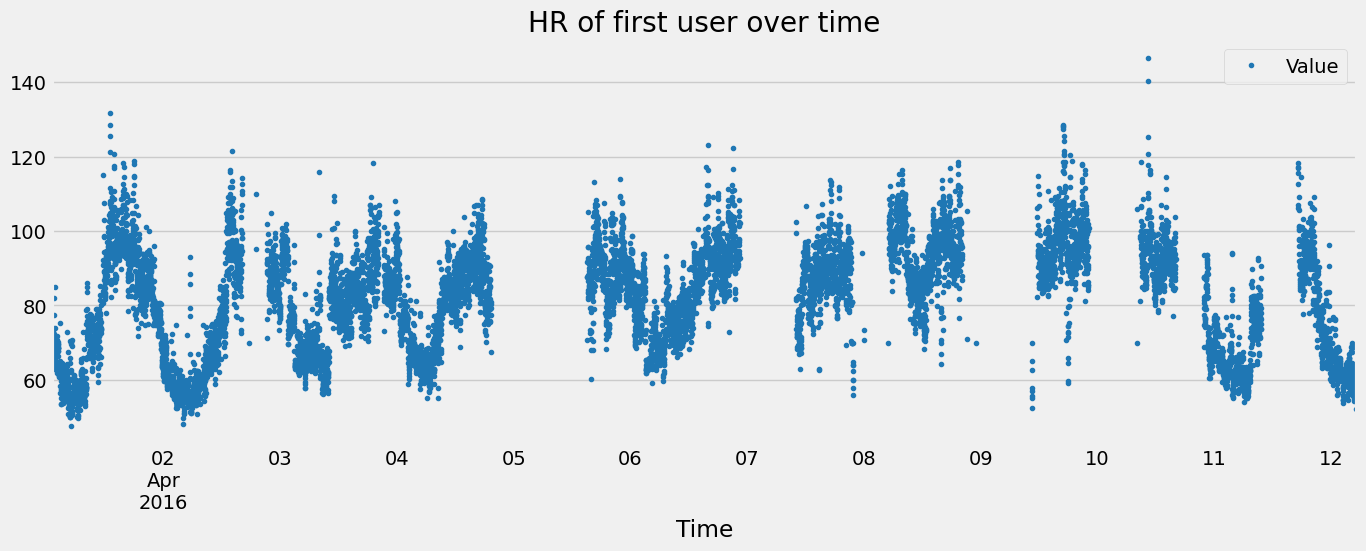

In [13]:
df_min.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='HR of first user over time')
plt.show()

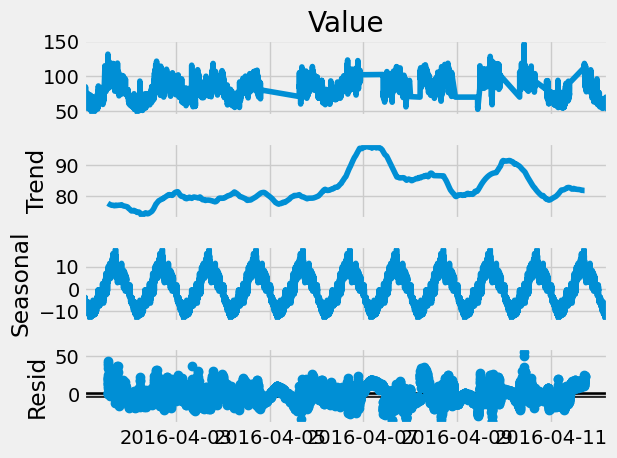

In [14]:
# Fill missing values by interpolation
df_min_filled = df_min['Value'].interpolate()

# Or, to simply drop missing values (may affect regularity)
# df_min_filled = df_min['Value'].dropna()

result = seasonal_decompose(df_min_filled, model='additive', period=60*24)
result.plot()
plt.show()

# Filling missing values with the average value for that minute across all days.

In [15]:
# Make sure 'Time' is the index and is datetime type
df_sorted = df_max_id.set_index('Time')
df_sorted.index = pd.to_datetime(df_sorted.index)

# Resample to 1-minute intervals (creates missing minutes as NaN)
df_min = df_sorted.resample('1T').mean(numeric_only=True)

# Extract minute of day for each timestamp
df_min['minute_of_day'] = df_min.index.hour * 60 + df_min.index.minute

# Compute average value for each minute of the day (across all days)
minute_avg = df_min.groupby('minute_of_day')['Value'].mean()

# Fill missing values with the average for that minute of the day
df_min['Value'] = df_min.apply(
    lambda row: minute_avg[row['minute_of_day']] if pd.isna(row['Value']) else row['Value'],
    axis=1
)

# Now df_min['Value'] has no missing values, and each missing minute is filled with its typical value

C:\Users\shiha\AppData\Local\Temp\ipykernel_11452\1242785015.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_min = df_sorted.resample('1T').mean(numeric_only=True)


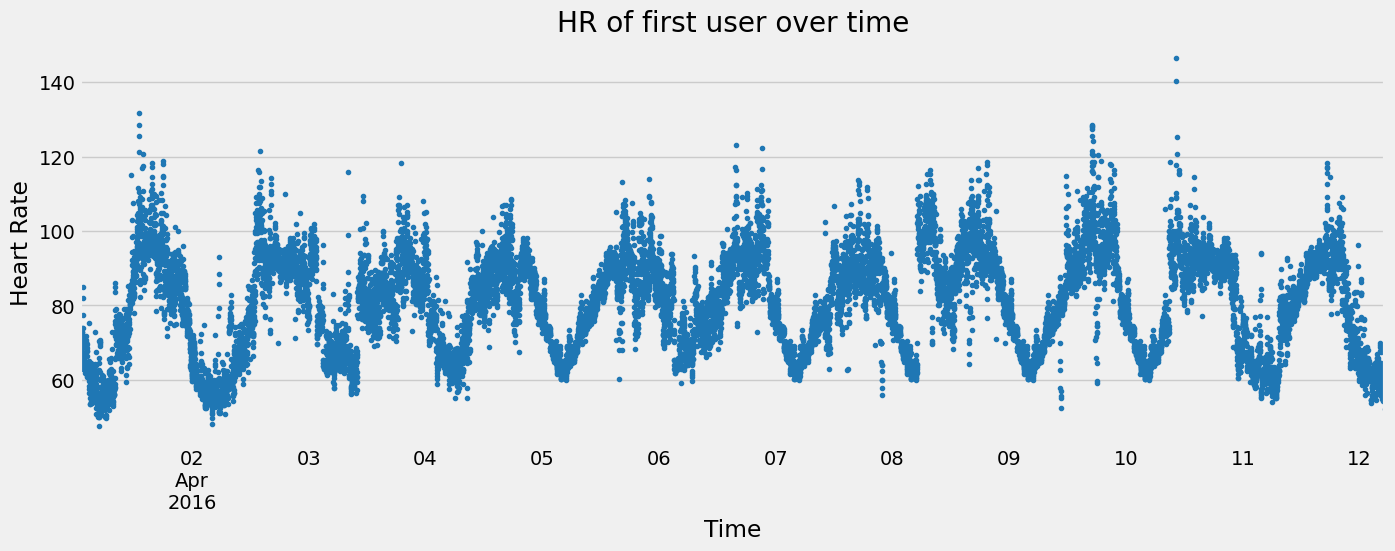

In [16]:
df_min['Value'].plot(
    style='.',
    figsize=(15, 5),
    color=color_pal[0],
    title='HR of first user over time'
)
plt.xlabel('Time')
plt.ylabel('Heart Rate')
plt.show()

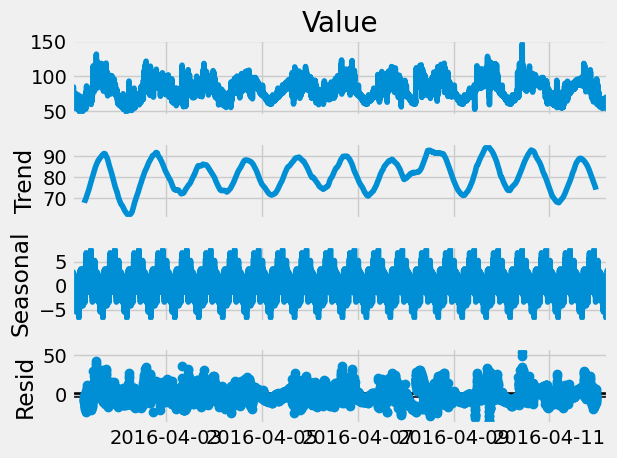

In [17]:
# Fill missing values by interpolation
df_min_filled = df_min['Value'].interpolate()

# Or, to simply drop missing values (may affect regularity)
# df_min_filled = df_min['Value'].dropna()

result = seasonal_decompose(df_min_filled, model='additive', period=60*12)
result.plot()
plt.show()

In [18]:
df_min_filled.head()

Time
2016-04-01 01:03:00    68.684211
2016-04-01 01:04:00    64.518519
2016-04-01 01:05:00    68.423077
2016-04-01 01:06:00    67.655172
2016-04-01 01:07:00    67.240000
Freq: min, Name: Value, dtype: float64

* # Train Test data 

<Figure size 640x480 with 0 Axes>

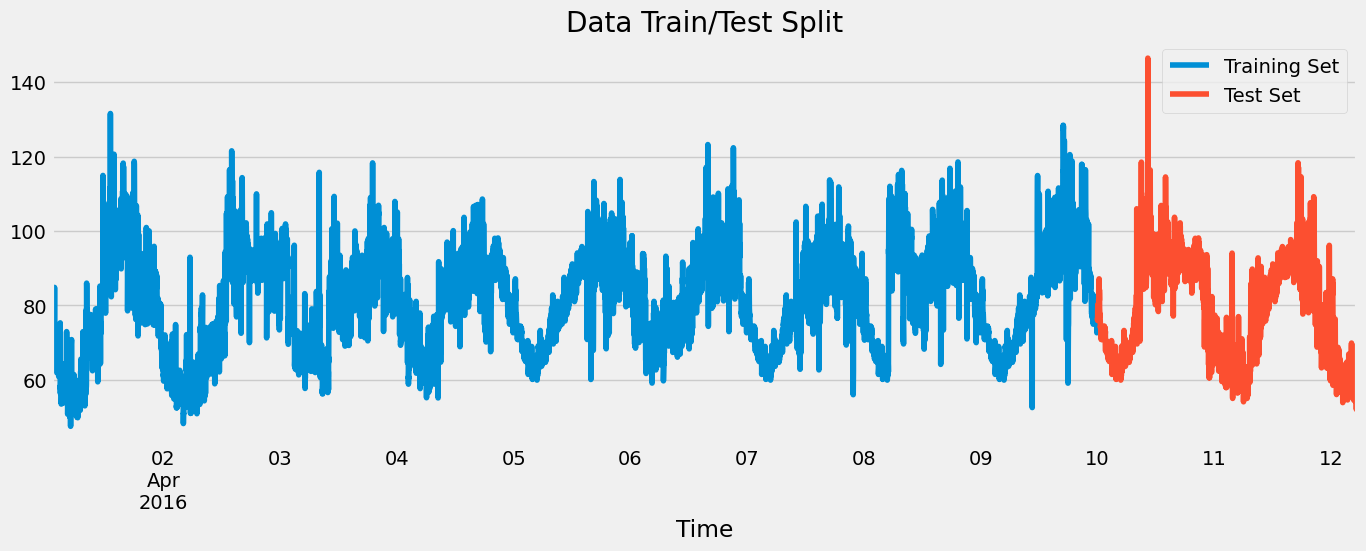

In [19]:
df=df_min_filled.to_frame()
train = df.loc[df.index < '2016-04-10']
test = df.loc[df.index >= '2016-04-10']
plt.clf()
fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('10-04-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

## Now in order to truly see the neural network's capacity we need to create a sequence so that it does capture the right patterns and lerans the most from those patterns.

In [20]:
def create_sequences(data, input_steps, output_steps, target_col_index):
    X, y = [], []

    for i in range(len(data) - input_steps - output_steps):
        input_seq = data[i : i + input_steps]
        output_seq = data[i + input_steps : i + input_steps + output_steps, target_col_index]

        X.append(input_seq)
        y.append(output_seq)

    return np.array(X), np.array(y)


In [21]:
INPUT_STEPS = 120 # past 2 hour
OUTPUT_STEPS = 1   # next minute
TARGET_INDEX = 0   # Index of 'Value' column


In [22]:
# Force NumPy arrays at the call site
X_train_seq, y_train_seq = create_sequences(
    train[['Value']].to_numpy(), INPUT_STEPS, OUTPUT_STEPS, TARGET_INDEX
)
X_test_seq,  y_test_seq  = create_sequences(
    test[['Value']].to_numpy(),  INPUT_STEPS, OUTPUT_STEPS, TARGET_INDEX
)


In [23]:
#lets check the shapes
# Check sequence and target shapes
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape :", X_test_seq.shape)
print("y_test_seq shape :", y_test_seq.shape)

# Optional — check timestamp alignment for test targets
timestamps_test = test.index[INPUT_STEPS:INPUT_STEPS + len(y_test_seq)]
print("timestamps_test length:", len(timestamps_test))
print("first few timestamps:", timestamps_test[:5])


X_train_seq shape: (12776, 120, 1)
y_train_seq shape: (12776, 1)
X_test_seq shape : (3079, 120, 1)
y_test_seq shape : (3079, 1)
timestamps_test length: 3079
first few timestamps: DatetimeIndex(['2016-04-10 02:00:00', '2016-04-10 02:01:00',
               '2016-04-10 02:02:00', '2016-04-10 02:03:00',
               '2016-04-10 02:04:00'],
              dtype='datetime64[ns]', name='Time', freq='min')


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the input shape (timesteps, features)
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])  # (60, 1)

# Build the model in your style, adjusted for 1-step prediction
lstm_model = Sequential()
lstm_model.add(LSTM(64, return_sequences=False, input_shape=input_shape))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))  # single next-minute value

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()


c:\Users\shiha\Downloads\Python 3.12\Heart Failure Project\venv312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras import callbacks

cb = [
    callbacks.EarlyStopping(monitor="val_mae", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mae", patience=4, factor=0.5)
]

history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,   # uses 20% of training data for validation
    epochs=100,
    batch_size=256,
    callbacks=cb,
    verbose=1
)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 6237.3091 - mae: 77.9108 - val_loss: 7081.1855 - val_mae: 83.1192 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 5480.9082 - mae: 72.8625 - val_loss: 6104.7559 - val_mae: 77.0344 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 4805.4766 - mae: 68.1159 - val_loss: 5607.1216 - val_mae: 73.7478 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 4431.5781 - mae: 65.3171 - val_loss: 5226.5659 - val_mae: 71.1102 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 4027.7190 - mae: 62.1350 - val_loss: 4734.8115 - val_mae: 67.5629 - learning_rate: 0.0010
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 3595.7529 - mae: 58.5520 - val_loss: 4269.0244 - val_mae: 64.0364 - learning_rate: 0.0010
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 3248.6345 - mae: 55.5154 - val_lo

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# predict on test
y_pred_lstm = lstm_model.predict(X_test_seq).ravel()

# metrics
mae_lstm  = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))


print("LSTM — Test Performance")
print(f"  • MAE : {mae_lstm:.3f}")
print(f"  • RMSE: {rmse_lstm:.3f}")



97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
LSTM — Test Performance
  • MAE : 2.250
  • RMSE: 3.878


In [ ]:
#Cnn model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Define CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])

cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
cnn_model.summary()


c:\Users\shiha\Downloads\Python 3.12\Heart Failure Project\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 118, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3776)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │       241,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,049 (945.50 KB)

 Trainable params: 242,049 (945.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import callbacks

cb_cnn = [
    callbacks.EarlyStopping(monitor="val_mae", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mae", patience=4, factor=0.5)
]

history_cnn = cnn_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=150,
    batch_size=256,
    callbacks=cb_cnn,
    verbose=1
)


Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 35.0949 - mae: 4.4343 - val_loss: 30.4487 - val_mae: 3.8378 - learning_rate: 0.0010
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 35.7153 - mae: 4.4745 - val_loss: 29.5149 - val_mae: 3.7696 - learning_rate: 0.0010
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 35.1758 - mae: 4.4542 - val_loss: 28.5360 - val_mae: 3.7043 - learning_rate: 0.0010
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 35.3020 - mae: 4.4780 - val_loss: 30.1045 - val_mae: 3.8965 - learning_rate: 0.0010
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 33.5716 - mae: 4.3565 - val_loss: 26.9091 - val_mae: 3.5988 - learning_rate: 0.0010
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 31.3055 - mae: 4.1772 - val_loss: 29.6395 - val_mae: 3.8949 - learning_rate: 0.0010
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 32.0805 - mae: 4.2273 - val_loss: 28.5385 - val_mae: 3.7975 - learning_rate:

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predict on test
y_pred_cnn = cnn_model.predict(X_test_seq).ravel()

# Compute metrics
mae_cnn  = mean_absolute_error(y_test_seq, y_pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(y_test_seq, y_pred_cnn))
r2_cnn   = r2_score(y_test_seq, y_pred_cnn)

print("CNN — Test Performance")
print(f"  • MAE : {mae_cnn:.3f}")
print(f"  • RMSE: {rmse_cnn:.3f}")



97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
CNN — Test Performance
  • MAE : 2.705
  • RMSE: 4.042


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dropout, Dense

# adjust input shape
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])  # (60, 1)

# build CNN-LSTM hybrid (3-step forecast)
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))  # 1minute ahead prediction

# compile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


c:\Users\shiha\Downloads\Python 3.12\Heart Failure Project\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 118, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,345 (130.25 KB)

 Trainable params: 33,345 (130.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Set parameters for 3-step prediction
INPUT_STEPS  = 120# past 60 minutes
OUTPUT_STEPS = 1   # predict next 3 minutes
TARGET_INDEX = 0    # column index for 'Value'

# Create multi-step sequences
X_train_seq, y_train_seq = create_sequences(train[['Value']].to_numpy(), INPUT_STEPS, OUTPUT_STEPS, TARGET_INDEX)
X_test_seq,  y_test_seq  = create_sequences(test[['Value']].to_numpy(),  INPUT_STEPS, OUTPUT_STEPS, TARGET_INDEX)

# Confirm shapes
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)


X_train_seq: (12776, 120, 1)
y_train_seq: (12776, 1)
X_test_seq: (3079, 120, 1)
y_test_seq: (3079, 1)


In [ ]:
from tensorflow.keras import callbacks

cb_cnnlstm = [
    callbacks.EarlyStopping(monitor="val_mae", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mae", patience=4, factor=0.5)
]

history_cnnlstm = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=cb_cnnlstm,
    verbose=1
)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 5697.4326 - mae: 74.3525 - val_loss: 6357.3682 - val_mae: 78.6705 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 5114.4253 - mae: 70.3528 - val_loss: 5949.4697 - val_mae: 76.0329 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 4679.2617 - mae: 67.1862 - val_loss: 5463.6836 - val_mae: 72.7692 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 4271.1528 - mae: 64.0747 - val_loss: 5051.4429 - val_mae: 69.8792 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 3926.5891 - mae: 61.3262 - val_loss: 4684.4326 - val_mae: 67.2022 - learning_rate: 0.0010
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 3631.5710 - mae: 58.8746 - val_loss: 4379.9316 - val_mae: 64.8971 - learning_rate: 0.0010
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 3374.9014 - mae: 56.6429 - val_loss: 409

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1️ Predict
y_pred_cnnlstm = model.predict(X_test_seq)

# 2️ Flatten to compare fairly
y_true_flat = y_test_seq.reshape(-1)
y_pred_flat = y_pred_cnnlstm.reshape(-1)

# 3️ Compute metrics
mae_cnnlstm  = mean_absolute_error(y_true_flat, y_pred_flat)
rmse_cnnlstm = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
r2_cnnlstm   = r2_score(y_true_flat, y_pred_flat)

print("CNN-LSTM — Test Performance")
print(f"  • MAE : {mae_cnnlstm:.3f}")
print(f"  • RMSE: {rmse_cnnlstm:.3f}")



97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
CNN-LSTM — Test Performance
  • MAE : 2.612
  • RMSE: 4.272


## Lets manualy try the LSTM 

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks

# same input shape as our sequences
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])  # (120, 1) in your file

# LSTM with lower LR and recurrent dropout
lstm_tuned = Sequential([
    LSTM(64, return_sequences=False, input_shape=input_shape),
    Dropout(0.2),
    Dense(1)
])

lstm_tuned.compile(optimizer=Adam, loss='mse', metrics=['mae'])

cb_lstm = [
    callbacks.EarlyStopping(monitor="val_mae", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mae", patience=5, factor=0.5)
]

history_lstm_tuned = lstm_tuned.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=150,
    batch_size=128,   # a bit smaller batch can help
    callbacks=cb_lstm,
    verbose=1
)


Epoch 1/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 6542.3569 - mae: 79.8600 - val_loss: 7685.9438 - val_mae: 86.6932 - learning_rate: 1.0000e-04
Epoch 2/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 6390.8086 - mae: 78.9034 - val_loss: 7500.1465 - val_mae: 85.6175 - learning_rate: 1.0000e-04
Epoch 3/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 6227.9814 - mae: 77.8603 - val_loss: 7304.7285 - val_mae: 84.4635 - learning_rate: 1.0000e-04
Epoch 4/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 6030.8745 - mae: 76.5764 - val_loss: 7083.7114 - val_mae: 83.1333 - learning_rate: 1.0000e-04
Epoch 5/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 5792.2012 - mae: 74.9865 - val_loss: 6794.8848 - val_mae: 81.3645 - learning_rate: 1.0000e-04
Epoch 6/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 5523.3188 - mae: 73.1809 - val_loss: 6514.8394 - val_mae: 79.6492 - learning_rate: 1.0000e-04
Epoch 7/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 5332.1904 - mae:

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# predict
y_pred_lstm_tuned = lstm_tuned.predict(X_test_seq).ravel()

# ensure same length (just in case)
n = min(len(y_test_seq), len(y_pred_lstm_tuned))
y_true_eval = y_test_seq[:n]
y_pred_eval = y_pred_lstm_tuned[:n]

# metrics
mae_t  = mean_absolute_error(y_true_eval, y_pred_eval)
rmse_t = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))


print("Tuned LSTM — Test Performance")
print(f"  • MAE : {mae_t:.3f}")
print(f"  • RMSE: {rmse_t:.3f}")



97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Tuned LSTM — Test Performance
  • MAE : 14.007
  • RMSE: 17.544


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the input shape (timesteps, features)
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])  # (120, 1)

# Build the model in your style, adjusted for 1-step prediction
lstm_Tunedmodel = Sequential()
lstm_Tunedmodel.add(LSTM(64, return_sequences=False, input_shape=input_shape))
lstm_Tunedmodel.add(Dropout(0.2))
lstm_Tunedmodel.add(Dense(1))  # single next-minute value

lstm_Tunedmodel.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_Tunedmodel.summary()


c:\Users\shiha\Downloads\Python 3.12\Heart Failure Project\venv312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import callbacks

cb = [
    callbacks.EarlyStopping(monitor="val_mae", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mae", patience=4, factor=0.5)
]

history_lstm_Tunedmodel = lstm_Tunedmodel.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,   # uses 20% of training data for validation
    epochs=100,
    batch_size=256,
    callbacks=cb,
    verbose=1
)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 6330.9370 - mae: 78.5139 - val_loss: 7208.9712 - val_mae: 83.8874 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 5633.1211 - mae: 73.9095 - val_loss: 6331.3940 - val_mae: 78.4972 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 4986.2803 - mae: 69.4187 - val_loss: 5682.6733 - val_mae: 74.2545 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 4390.3872 - mae: 64.9851 - val_loss: 5081.0845 - val_mae: 70.0898 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 3914.3621 - mae: 61.2145 - val_loss: 4611.9004 - val_mae: 66.6604 - learning_rate: 0.0010
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 3540.5115 - mae: 58.0911 - val_loss: 4248.2080 - val_mae: 63.8744 - learning_rate: 0.0010
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 3245.7322 - mae: 55.4907 - val_loss: 39

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on test
y_pred_lstm_tuned = lstm_Tunedmodel.predict(X_test_seq).ravel()

# Calculate metrics
mae_lstm_tuned  = mean_absolute_error(y_test_seq, y_pred_lstm_tuned)
rmse_lstm_tuned = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm_tuned))


# Print results cleanly
print("Tuned LSTM — Test Performance")
print(f"  • MAE : {mae_lstm_tuned:.3f}")
print(f"  • RMSE: {rmse_lstm_tuned:.3f}")



97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Tuned LSTM — Test Performance
  • MAE : 2.500
  • RMSE: 4.211


## Lets add the bayesian tuning for the lstm model

In [29]:
# ---- Bayesian tuning for LSTM base model (1-step) ----
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# infer input shape from your sequences
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])  # e.g., (120, 1)

def build_lstm_base(hp: kt.HyperParameters):
    model = Sequential()

    # how many LSTM layers (1 or 2)
    num_layers = hp.Int("num_lstm_layers", min_value=1, max_value=2)

    # first LSTM
    units_0 = hp.Int("lstm_units_0", min_value=32, max_value=128, step=16)
    model.add(LSTM(units_0, return_sequences=(num_layers == 2), input_shape=input_shape))

    # optional second LSTM
    if num_layers == 2:
        units_1 = hp.Int("lstm_units_1", min_value=32, max_value=128, step=16)
        model.add(LSTM(units_1, return_sequences=False))

    # dropout
    drop = hp.Float("dropout", min_value=0.0, max_value=0.4, step=0.1)
    model.add(Dropout(drop))

    # output: 1-step ahead
    model.add(Dense(1))

    # optimizer LR
    lr = hp.Float("learning_rate", min_value=1e-4, max_value=3e-3, sampling="log")
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

tuner = kt.BayesianOptimization(
    build_lstm_base,
    objective="val_mae",
    max_trials=25,                  # increase if you want a deeper search
    executions_per_trial=1,
    directory="tuner_hr",
    project_name="lstm_base_bayes"
)

early = EarlyStopping(monitor="val_mae", patience=8, restore_best_weights=True)

tuner.search(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=80,
    batch_size=256,
    callbacks=[early],
    verbose=1
)

tuner.results_summary()
best_lstm = tuner.get_best_models(1)[0]
best_lstm.summary()


Trial 25 Complete [00h 04m 51s]
val_mae: 3.0234134197235107

Best val_mae So Far: 2.6476356983184814
Total elapsed time: 05h 02m 58s
Results summary
Results in tuner_hr\lstm_base_bayes
Showing 10 best trials
Objective(name="val_mae", direction="min")

Trial 20 summary
Hyperparameters:
num_lstm_layers: 2
lstm_units_0: 64
dropout: 0.0
learning_rate: 0.003
lstm_units_1: 128
Score: 2.6476356983184814

Trial 15 summary
Hyperparameters:
num_lstm_layers: 1
lstm_units_0: 112
dropout: 0.0
learning_rate: 0.003
lstm_units_1: 128
Score: 2.676382064819336

Trial 18 summary
Hyperparameters:
num_lstm_layers: 1
lstm_units_0: 128
dropout: 0.1
learning_rate: 0.003
lstm_units_1: 64
Score: 2.896426200866699

Trial 22 summary
Hyperparameters:
num_lstm_layers: 2
lstm_units_0: 32
dropout: 0.4
learning_rate: 0.003
lstm_units_1: 128
Score: 2.9089865684509277

Trial 24 summary
Hyperparameters:
num_lstm_layers: 1
lstm_units_0: 80
dropout: 0.30000000000000004
learning_rate: 0.003
lstm_units_1: 128
Score: 3.023413

c:\Users\shiha\Downloads\Python 3.12\Heart Failure Project\venv312\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 120, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,841 (452.50 KB)

 Trainable params: 115,841 (452.50 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the input shape (timesteps, features)
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

# Build the tuned model from Trial 20
lstm_model = Sequential()

# First LSTM layer (64 units, returns sequences)
lstm_model.add(LSTM(64, return_sequences=True, input_shape=input_shape))

# Second LSTM layer (128 units)
lstm_model.add(LSTM(128, return_sequences=False))

# Dropout (tuned: 0.0 → so no dropout layer needed)
# lstm_model.add(Dropout(0.0))  # Not needed

# Final output layer (1-step prediction)
lstm_model.add(Dense(1))

# Compile with the tuned learning rate
optimizer = Adam(learning_rate=0.003)
lstm_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

lstm_model.summary()


c:\Users\shiha\Downloads\Python 3.12\Heart Failure Project\venv312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 120, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,841 (452.50 KB)

 Trainable params: 115,841 (452.50 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_mae',
    patience=8,
    restore_best_weights=True
)

# Train the model
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=80,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 333ms/step - loss: 3973.0259 - mae: 61.3208 - val_loss: 3617.2563 - val_mae: 58.7278
Epoch 2/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 356ms/step - loss: 2158.7874 - mae: 44.4836 - val_loss: 2168.6848 - val_mae: 44.7257
Epoch 3/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 369ms/step - loss: 1187.4342 - mae: 31.8337 - val_loss: 1287.9272 - val_mae: 33.4614
Epoch 4/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 377ms/step - loss: 645.7484 - mae: 22.0822 - val_loss: 779.8619 - val_mae: 24.7822
Epoch 5/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 374ms/step - loss: 369.3590 - mae: 15.9123 - val_loss: 503.4926 - val_mae: 19.1183
Epoch 6/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 374ms/step - loss: 242.4841 - mae: 12.8934 - val_loss: 360.4844 - val_mae: 15.9113
Epoch 7/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 375ms/step - loss: 190.5463 - mae: 11.5488 - val_loss: 288.7973 - val_mae: 14.1534
Epoch 8/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 378ms/step - loss: 171.6579 - mae: 11.0160 - val_loss: 253.3367 - val_mae: 13

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# predict on test
y_pred_lstm = lstm_model.predict(X_test_seq).ravel()

# metrics
mae_lstm  = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))

print("Bayesian LSTM — Test Performance")
print(f"  • MAE : {mae_lstm:.3f}")
print(f"  • RMSE: {rmse_lstm:.3f}")


97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step
Bayesian LSTM — Test Performance
  • MAE : 12.348
  • RMSE: 13.812
